In [ ]:
# Model Predication steps (Linear Regression)
#1. Collect and Dataset
#2. EDA (Exploratory Data Analysis)
#3. Features Extraction(selection)
#4. Extract Input and output columns (Independent and Dependend variables)
#5. Scaling
#6. Train Test Split (Divide data into training and testing)
#7. Train Model
#8. Select proper model (Evaluate the model)
#9. Deploy the model

**Univariate analysis** refers to the examination of a single variable to understand its distribution and characteristics. The prefix "uni" signifies "one," indicating that this analysis focuses on one variable at a time. The primary goal is to summarize and describe the variable's distribution without exploring relationships with other variables.

In [ ]:
#Import required libraries
#Import Panda Library -  data analysis and manipulation/CSV file I/O (e.g. pd.read_csv)
import pandas as pd

# The Matplotlib library - creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Seaborn visualization library built on top of Matplotlib.
# It provides a high-level interface for creating attractive and informative statistical graphics.
import seaborn as sns

In [ ]:
from google.colab import files
# Choose your file from local system - Sports data set - NBA_player_of_the_week.csv - Found missing 500 rows in this data set.
# Choose your file from local system - Sports data set - NBA_player_of_the_week_update.csv - after fill the values.
files.upload()  # Choose your file from local system - Sports data set - NBA_player_of_the_week.csv - Found missing 500 rows in this data set.

Saving NBA_player_of_the_week_Updated.csv to NBA_player_of_the_week_Updated.csv


{'NBA_player_of_the_week_Updated.csv': b'Player,Team,Conference,Date,Position,Height,Weight,Age,Draft Year,Seasons in league,Season,Season short,Pre-draft Team,Real_value,Height CM,Weight KG,Last Season\r\nNorman Powell,Toronto Raptors,East,9/3/2020,SG,6\'4,215,26,2015,4,2019-2020,2020,UCLA,0.5,193,97,1\r\nLeBron James,Los Angeles Lakers,West,9/3/2020,F,6\'8,250,35,2003,16,2019-2020,2020,St. Vincent St. Mary High School (Ohio),0.5,203,113,1\r\nGiannis Antetokounmpo,Milwaukee Bucks,East,2/3/2020,F,6\'11,242,25,2013,6,2019-2020,2020,Filathlitikos Div II Greece (Greece),0.5,211,109,1\r\nKristaps Porzingis,Dallas Mavericks,West,2/3/2020,FC,7\'3,240,24,2015,4,2019-2020,2020,Real Betis Energia Plus (Spain),0.5,221,108,1\r\nJayson Tatum,Boston Celtics,East,10/2/2020,SF,6\'8,208,21,2017,2,2019-2020,2020,Duke,0.5,203,94,1\r\nNikola Jokic,Denver Nuggets,West,10/2/2020,C,7\'0,250,25,2014,4,2019-2020,2020,KK Mega Bemax (Serbia),0.5,213,113,1\r\nJaylen Brown,Boston Celtics,East,3/2/2020,SF,6\'7,220

In [ ]:
# Objective of the Analysis
# To understand the distribution and trends of NBA Player of the Week awards over time, focusing on:
# Frequency of awards per player
# Distribution across teams
# This helps uncover patterns in player performance recognition.

In [ ]:
#Step 1: Load the dataset in a data frame
sports_df = pd.read_csv("NBA_player_of_the_week_Updated.csv")

# Print the DataFrame
print(sports_df)

                      Player                 Team Conference        Date  \
0              Norman Powell      Toronto Raptors       East    9/3/2020   
1               LeBron James   Los Angeles Lakers       West    9/3/2020   
2      Giannis Antetokounmpo      Milwaukee Bucks       East    2/3/2020   
3         Kristaps Porzingis     Dallas Mavericks       West    2/3/2020   
4               Jayson Tatum       Boston Celtics       East   10/2/2020   
...                      ...                  ...        ...         ...   
1339               Phil Ford    Kansas City Kings       West  18/11/1979   
1340           Magic Johnson   Los Angeles Lakers       West  11/11/1979   
1341         Marques Johnson      Milwaukee Bucks       East   4/11/1979   
1342  Micheal Ray Richardson      New York Knicks       East  28/10/1979   
1343           Julius Erving  Philadelphia Sixers       East  21/10/1979   

     Position Height  Weight  Age  Draft Year  Seasons in league     Season  \
0       

In [ ]:
#Step 2: Explore data, clean up data and fix the issues
#Information about data types
print ("--- Information about data types ---")
sports_df.info()
print ("=====================================")
print("")
# SUMMARIZE the findings about the dataset to remember easily
# It returns a tuple(rows and columns) representing the dimensionality of the Pandas DataFrame.
print ("--- Shape (Rows and Columns) ---")
print ("Shape:", sports_df.shape)
print ("=====================================")
print("")

#Checking null values
print ("--- Check for missing values ---")
print ("\bMissing Values\n",  sports_df.isnull().sum()) # Missing values get mapped to True, and non-missing value gets mapped to False.
print ("=====================================")

--- Information about data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player             1344 non-null   object 
 1   Team               1344 non-null   object 
 2   Conference         1344 non-null   object 
 3   Date               1344 non-null   object 
 4   Position           1344 non-null   object 
 5   Height             1344 non-null   object 
 6   Weight             1344 non-null   int64  
 7   Age                1344 non-null   int64  
 8   Draft Year         1344 non-null   int64  
 9   Seasons in league  1344 non-null   int64  
 10  Season             1344 non-null   object 
 11  Season short       1344 non-null   int64  
 12  Pre-draft Team     1344 non-null   object 
 13  Real_value         1344 non-null   float64
 14  Height CM          1344 non-null   int64  
 15  Weight KG          1344 non-null   

In [ ]:
# This method returns a Series with the data type of each column.
print ("\nData Types\n",  sports_df.dtypes)


Data Types
 Player                object
Team                  object
Conference            object
Date                  object
Position              object
Height                object
Weight                 int64
Age                    int64
Draft Year             int64
Seasons in league      int64
Season                object
Season short           int64
Pre-draft Team        object
Real_value           float64
Height CM              int64
Weight KG              int64
Last Season            int64
dtype: object


In [ ]:
# Return a statistically description of the data in the DataFrame
sports_df.describe(include='object')  # For categorical columns

,Player,Team,Conference,Date,Position,Height,Season,Pre-draft Team
count,1344,1344,1344,1344,1344,1344,1344,1344
unique,334,37,2,918,11,21,41,169
top,LeBron James,Los Angeles Lakers,East,12/1/2003,G,6'9,2002-2003,St. Vincent St. Mary High School (Ohio)
freq,64,88,897,3,200,158,47,64


#Objective: To understand the distribution and trends of NBA Player of the Week awards over time.
#1- Frequency of awards per player
#2- Disturibution across teams.
#3- Disuribution across seasons.

In [ ]:
# Unique values and distributions based on multiple scenarios
# Objective: Identify players with the most awards.
sports_df['Player'].value_counts().head(10)  # Top 10 most awarded players

,count
Player,
LeBron James,64
Kobe Bryant,33
Kevin Durant,26
Michael Jordan,25
James Harden,24
Karl Malone,23
Allen Iverson,23
Tim Duncan,23
Kevin Garnett,20


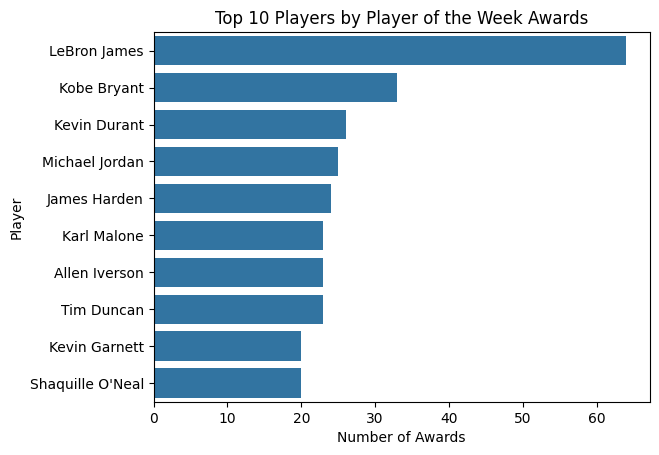

In [ ]:
# Draw a graph to visually present player acheivements
top_players = sports_df['Player'].value_counts().head(10)
sns.barplot(x=top_players.values, y=top_players.index)
plt.title('Top 10 Players by Player of the Week Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.show()

## **LeBron James** and **Kobe Bryant** dominate the chart, indicating consistent high performance across seasons.

In [ ]:
# Objective: To identify which team have the most recognized players.
sports_df['Team'].value_counts().head(10)    # Top 10 teams

,count
Team,
Los Angeles Lakers,88
Houston Rockets,68
San Antonio Spurs,68
Cleveland Cavaliers,62
Miami Heat,59
Boston Celtics,57
Utah Jazz,56
Denver Nuggets,52
Golden State Warriors,52


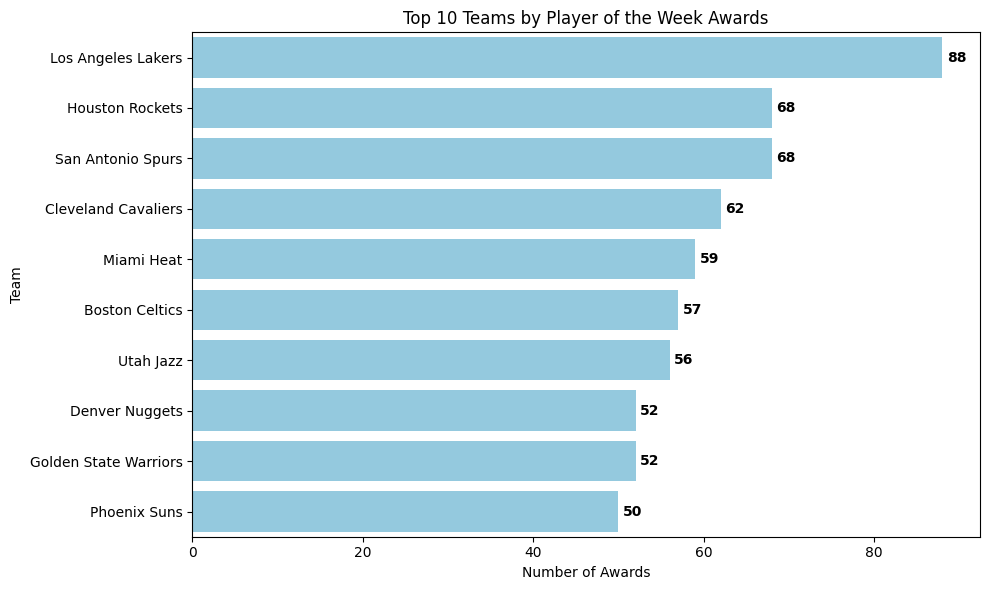

In [ ]:
# Draw a graph to visually present player acheivements
top_teams = sports_df['Team'].value_counts().head(10)

plt.figure(figsize=(10, 6))
# Create Axes object (ax) to control over the plot
ax = sns.barplot(x=top_teams.values, y=top_teams.index, color='skyblue')
plt.title('Top 10 Teams by Player of the Week Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Team')

# Add value labels to each bar
for barCounter, value in enumerate(top_teams.values):
    ax.text(value + 0.5, barCounter, str(value), va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

**Los Angeles Lakers** received a higher total of awards, tallying up to 88, while the **Phoenix Suns** only secured 50 awards among the leading 10 teams. suggesting Los Angeles Lakers have more **star players** during the time span.

In [ ]:
# Objective: To identify which season have the most recognized players.
# how many times each season appears. By default, it's sorted by frequency (most to least).
sports_df['Season'].value_counts().sort_index()  # Awards per season

,count
Season,
1979-1980,23
1980-1981,24
1981-1982,23
1982-1983,24
1983-1984,23
1984-1985,23
1985-1986,23
1986-1987,23
1987-1988,23


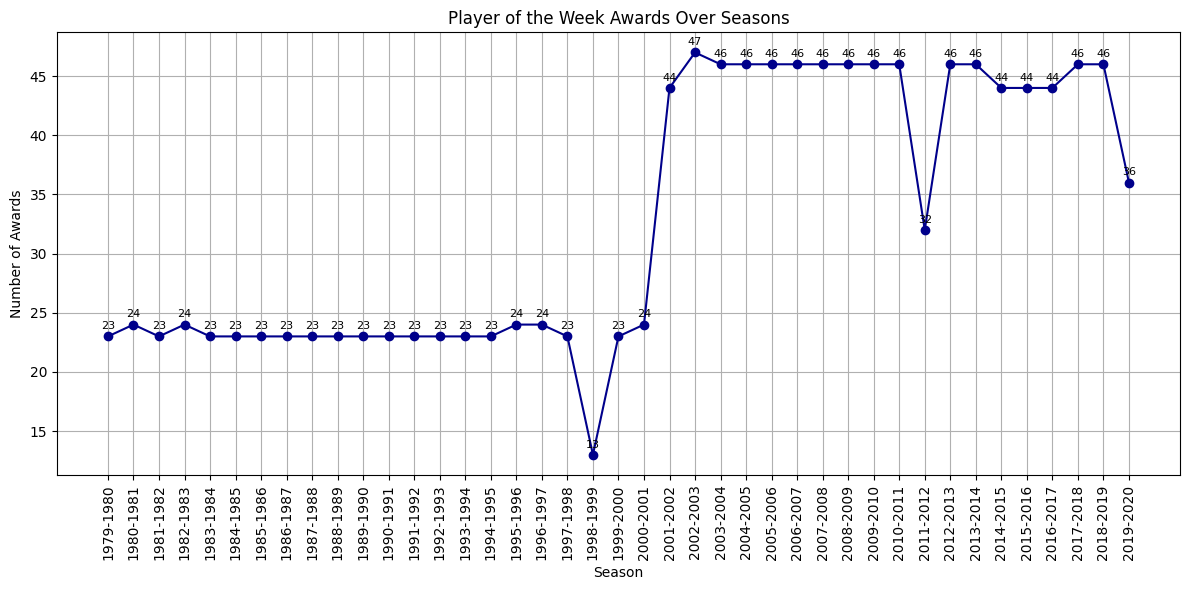

In [ ]:
# Draw a graph to visually present season acheivements
# Using a line plot to visualize how the number of "Player of the Week" awards changes over time, specifically across different seasons.
season_counts = sports_df['Season'].value_counts().sort_index()
seasons = list(season_counts.index)
counts = list(season_counts.values)

# Use integer positions for x-axis
x_positions = list(range(len(seasons))) # starts from 0

plt.figure(figsize=(12, 6))
plt.plot(x_positions, counts, marker='o', color='darkblue')

# Set correct season labels at integer positions
plt.xticks(ticks=x_positions, labels=seasons, rotation=90)

# Add value labels
# Combines the x-axis positions with their corresponding y-values (award counts).
# zip(x_positions, counts)
# plt.text(horizontal position (where the dot is), slightly above the dot to avoid overlap,
# converts the number to a string so it can be displayed.
for x, count in zip(x_positions, counts):
    plt.text(x, count + 0.6, str(count), ha='center', fontsize=8)

# Titles and layout
plt.title('Player of the Week Awards Over Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Awards')
plt.grid(True)
plt.tight_layout()
plt.show()

The line graph above visually displays the variations in the awards count throughout various seasons, starting from the first season to the latest one.